# `jlegroup.EPQ03` — light-curve inversion

**Elliot, Person & Qu 2003**, AJ 126, 1041 — *"Analysis of Stellar Occultation Data. II. Inversion, with Application to Pluto and Triton"*.

The forward problem (EY92, CE97) turns an atmosphere into a light curve; EPQ03 goes the other way. Above the **inversion boundary** the data are represented by a fitted EY92 model; below it, each flux sample peels off an atmospheric shell (an "onion peel"), accumulating refractivity, number-density, pressure, and temperature profiles — with the paper's full random-error propagation (Sec. 4).

Scope, exactly as published: **clear** (refraction-only) atmospheres, **one limb**, and a light curve normalized so the unocculted flux is 1 and the fully-occulted flux is 0 — *normalization is the caller's responsibility, and it dominates the systematics on real data*. Data must be in **immersion order** (shadow radius $y$ strictly decreasing).

Contents:
1. A synthetic occultation (the paper's standard test case)
2. Noiseless inversion — exact recovery
3. A realistic noisy inversion
4. The error budget
5. A thermal-gradient atmosphere
6. Gotchas & citation

Companions: [overview](00_jlegroup_overview.ipynb) · [EY92](01_EY92_basics.ipynb) · [CE97](02_CE97_basics.ipynb)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jlegroup
from jlegroup import EPQ03

print("jlegroup", jlegroup.__version__)

jlegroup 0.11.0


## 1. A synthetic occultation

`EPQ03.STANDARD_CASE` is the paper's Table-1 test atmosphere: isothermal 80 K N₂, half-light radius $r_h = 1200$ km, energy ratio $\lambda_h = 40$ (scale height $H_h = 30$ km), observed from 30 AU. `generate_light_curve` samples the EY92 forward model on the paper's 0.5 km grid, immersion-ordered — the same setup the module's own validation uses. (This notebook runs at the package-default CODATA-2022 constants; the module's paper-digit validation pins `constants=CODATA1986`, the paper era's vintage — everything here is self-consistent under either.)

r_h = 1200.0 km, lambda_h = 40.0, H_h = 30.0 km, T_h = 80.0 K, M_p = 1.7078e+22 kg


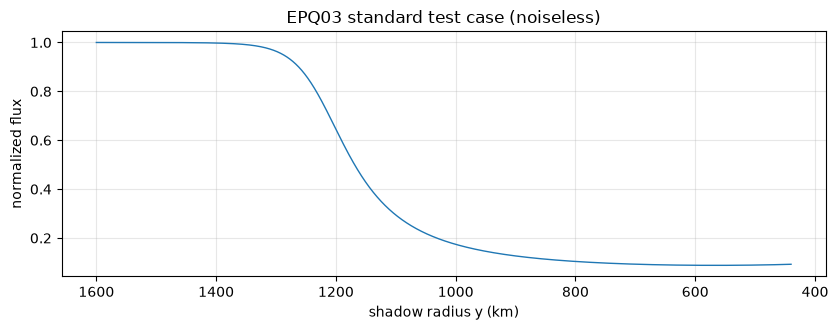

In [2]:
atm = EPQ03.STANDARD_CASE
M_p = atm.mass()
print(f"r_h = {atm.r_h} km, lambda_h = {atm.lambda_h}, H_h = {atm.h_h} km, "
      f"T_h = {atm.t_h} K, M_p = {M_p:.4e} kg")

y, phi = EPQ03.generate_light_curve(atm, y_top=1600.0, y_bottom=440.0)   # 0.5 km steps

plt.figure(figsize=(8.5, 3.4))
plt.plot(y, phi, lw=1)
plt.gca().invert_xaxis()          # immersion: time runs left to right
plt.xlabel("shadow radius y (km)"); plt.ylabel("normalized flux")
plt.title("EPQ03 standard test case (noiseless)")
plt.grid(alpha=0.3); plt.tight_layout()

## 2. Noiseless inversion — exact recovery

`invert_light_curve` needs the light curve plus three physical facts: observer distance, gas, and body mass. Everything else defaults to the paper's choices — it fits an `EY92PowerLawBoundary` to the data above half light (`boundary_flux=0.5` selects the first inversion sample $i_b$), then inverts below. Noiseless synthetic data is the round-trip test: the fit should recover the generating parameters and the retrieved temperature should be the input 80 K.

boundary fit vs truth:
  r_h       = 1200.000000 km   (true 1200.0)
  lambda_hi = 40.000000      (true 40.0)
  b         = 3.90e-11       (true 0.0)
retrieved T, 10 deepest shells: 79.9978 +/- 0.0001 K


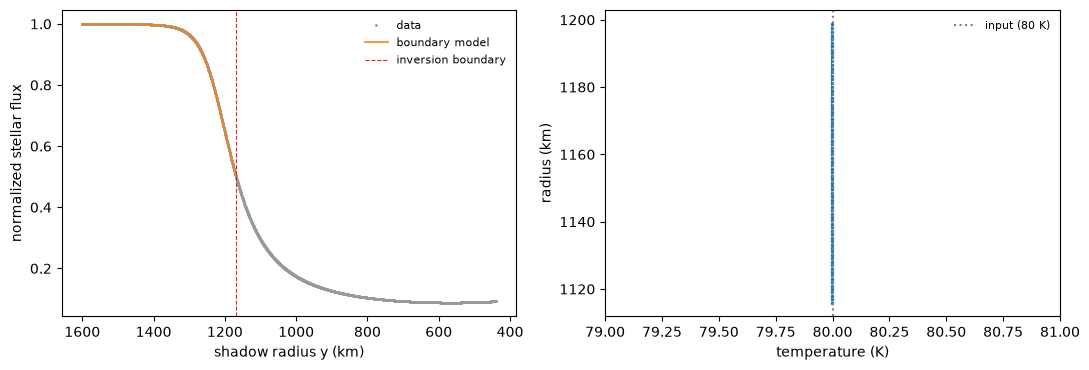

In [3]:
res = EPQ03.invert_light_curve(y, phi, d=atm.d, gas=atm.gas, m_p=M_p,
                               order=atm.order)

bc = res.boundary
print("boundary fit vs truth:")
print(f"  r_h       = {bc.r_h:.6f} km   (true {atm.r_h})")
print(f"  lambda_hi = {bc.lambda_hi:.6f}      (true {atm.lambda_hi})")
print(f"  b         = {bc.b:.2e}       (true {atm.b})")
t = res.temperature
print(f"retrieved T, 10 deepest shells: {t[-10:].mean():.4f} +/- {t[-10:].std():.4f} K")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
EPQ03.plot_light_curve(res, ax=ax[0])
EPQ03.plot_temperature(res, ax=ax[1])
ax[1].axvline(80.0, color="gray", ls=":", label="input (80 K)")
ax[1].set_xlim(79, 81); ax[1].legend(frameon=False, fontsize=8)
fig.tight_layout()

## 3. A realistic noisy inversion

The noise convention is background-limited white Gaussian noise of constant rms, quantified per scale height: $(S/N)_H = \sigma^{-1}\sqrt{H/\Delta y}$ [Eq. 99]. Two analyst's choices from Sec. 7.3 matter on noisy data:

- **Fix $i_b$ deliberately** (here from the noiseless boundary crossing; on real data, from judgment) — otherwise noise spikes near flux 0.5 move the boundary between realizations.
- **Fit only the boundary parameters the data constrain:** for an isothermal atmosphere fit `("r_h", "lambda_hi")` and leave $b = 0$, rather than letting noise excite the $\lambda$–$b$ degeneracy.

per-point sigma = 0.0775   ((S/N)_H = 100)
boundary fit: r_h = 1200.24 km, lambda_hi = 39.24


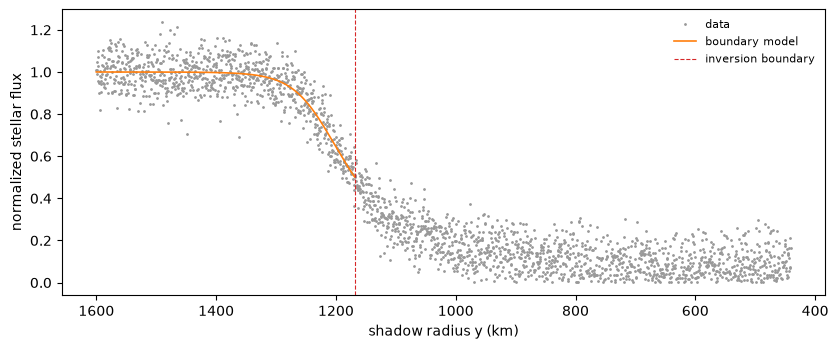

In [4]:
snr_h = 100.0
sigma = EPQ03.sigma_from_snr_h(snr_h, atm.h_h, 0.5)     # per-point flux rms
phi_noisy, sig = EPQ03.add_noise(phi, sigma, np.random.default_rng(0))
i_b = EPQ03.boundary_index(phi, 0.5)                    # deliberate boundary choice

res_n = EPQ03.invert_light_curve(
    y, phi_noisy, sig, d=atm.d, gas=atm.gas, m_p=M_p,
    order=atm.order, i_b=i_b, fit_params=("r_h", "lambda_hi"),
)
print(f"per-point sigma = {sigma:.4f}   ((S/N)_H = {snr_h:g})")
print(f"boundary fit: r_h = {res_n.boundary.r_h:.2f} km, "
      f"lambda_hi = {res_n.boundary.lambda_hi:.2f}")

ax = EPQ03.plot_light_curve(res_n)
ax.figure.set_size_inches(8.5, 3.6)
ax.figure.tight_layout()

## 4. The error budget

`propagate_errors` implements the paper's Sec.-4 propagation: every retrieved quantity gets a per-shell σ, split into a **boundary** term (uncertainty of the fitted boundary parameters, correlated between shells) and a **summation** term (photon noise accumulated down the onion peel) [Eq. 72]. Near the top the boundary term dominates; at depth the summation noise takes over — the paper's Fig.-10 morphology. `result_table` collects everything in the layout of the paper's Tables 11–14 (and `write_csv` saves it).

,y_km,delta_y_km,flux,sigma_flux,r_km,refractivity,number_density_cm3,pressure_microbar,temperature_K,scale_height_km,sigma_r_km,sigma_refractivity,sigma_number_density_cm3,sigma_pressure_microbar,sigma_temperature_K,sigma_scale_height_km,sigma_temperature_boundary_K,sigma_temperature_summation_K
72,628.500,-22.625,0.0938,0.0125,1122.3531,0.0,6.374485e+14,7.2754,82.6667,27.1180,1.3248,0.0,7.227538e+12,0.1915,1.4135,0.4379,0.6482,1.2561
73,605.500,-23.500,0.0863,0.0118,1121.2582,0.0,6.639466e+14,7.5755,82.6412,27.0568,1.3346,0.0,7.523472e+12,0.1994,1.4111,0.4351,0.6268,1.2643
74,584.500,-18.500,0.1070,0.0131,1120.2262,0.0,6.892904e+14,7.8703,82.6996,27.0261,1.3418,0.0,7.653576e+12,0.2060,1.4096,0.4328,0.6073,1.2721
75,564.375,-21.875,0.0982,0.0122,1119.1438,0.0,7.166764e+14,8.1920,82.7910,27.0037,1.3498,0.0,7.865666e+12,0.2135,1.4079,0.4303,0.5876,1.2795
76,540.750,-25.125,0.0928,0.0119,1118.0162,0.0,7.465832e+14,8.5415,82.8653,26.9735,1.3589,0.0,8.185411e+12,0.2222,1.4058,0.4277,0.5673,1.2863
77,516.375,-23.875,0.0960,0.0115,1116.9573,0.0,7.758206e+14,8.8837,82.9371,26.9458,1.3661,0.0,8.376568e+12,0.2298,1.4037,0.4252,0.5488,1.2920
78,491.750,-25.125,0.0987,0.0115,1115.8648,0.0,8.070762e+14,9.2515,83.0256,26.9218,1.3733,0.0,8.589660e+12,0.2379,1.4011,0.4226,0.5301,1.2969
79,466.250,-26.000,0.0995,0.0113,1114.7834,0.0,8.392119e+14,9.6308,83.1201,26.9002,1.3802,0.0,8.800521e+12,0.2461,1.3980,0.4199,0.5120,1.3009


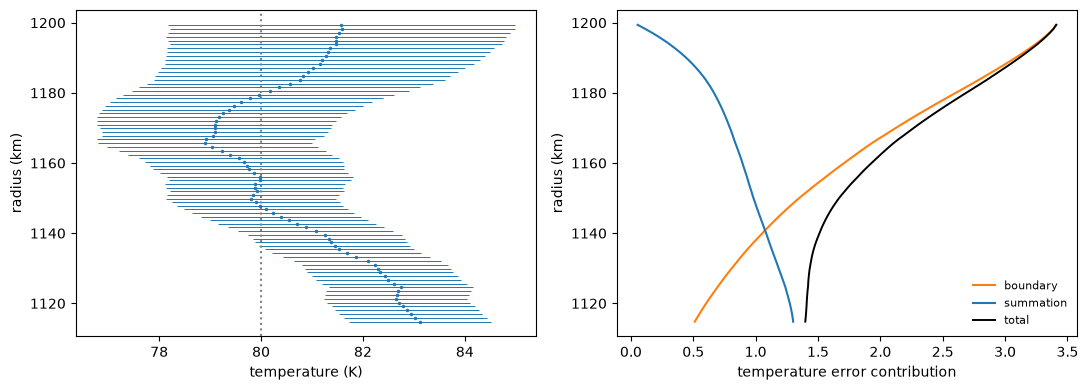

In [5]:
budget = EPQ03.propagate_errors(res_n)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
EPQ03.plot_temperature(res_n, budget, ax=ax[0])
ax[0].axvline(80.0, color="gray", ls=":")
EPQ03.plot_error_decomposition(res_n, budget, "temperature", ax=ax[1])
fig.tight_layout()

table = pd.DataFrame(EPQ03.result_table(res_n, budget))
table.tail(8).round(4)

## 5. A thermal-gradient atmosphere

`standard_case_variant(b=...)` keeps $\lambda_h = 40$ and imposes $T \propto r^b$. The inversion — now fitting all three boundary parameters again — tracks the model profile within the paper's Fig.-6 envelope (worst documented case, $b = 9$: 0.48%).

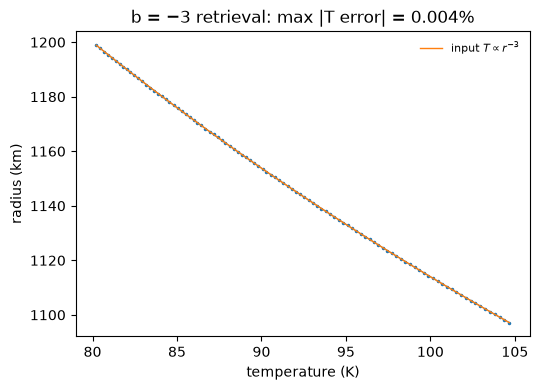

In [6]:
atm_b = EPQ03.standard_case_variant(b=-3.0)
y_g, phi_g = EPQ03.generate_light_curve(atm_b, 1600.0, 440.0)
res_b = EPQ03.invert_light_curve(y_g, phi_g, d=atm_b.d, gas=atm_b.gas,
                                 m_p=atm_b.mass(), order=atm_b.order)

r = res_b.grid.r_lower
t_true = 80.0 * (r / 1200.0) ** atm_b.b
ax = EPQ03.plot_temperature(res_b)
ax.plot(t_true, r, "-", color="C1", lw=1, label=r"input $T \propto r^{-3}$")
ax.legend(frameon=False, fontsize=8)
pct = 100 * np.abs(res_b.temperature / t_true - 1).max()
ax.set_title(f"b = $-3$ retrieval: max |T error| = {pct:.3f}%")
ax.figure.set_size_inches(5.5, 4)
ax.figure.tight_layout()

## 6. Ratchet binning (W. Saunders)

The positivity averaging lets the *noise realization* set the deep binning: a point that fluctuates positive keeps full resolution (a truncated, positively-biased selection), while a merge stops the moment its running mean crosses zero (clipped barely-positive). The lower tail of the noise distribution is structurally deleted, and at low $(S/N)_H$ the deep profile comes out **biased hot by several formal sigmas** with scatter *below* the propagated errors — spurious stability, visible as the hot deep bend of the paper's own Fig.-9 low-S/N sample.

**Ratchet binning** — conceived by Will Saunders during his PhD-thesis work with this methodology — makes the bin size a monotone ratchet: once positivity has forced a merge of $k$ points, every later bin starts at $k$. Binning then tracks the S/N envelope rather than the individual noise draws, restoring honest deep statistics at the cost of resolution at the lowest flux levels. It is **off by default** (the published scheme remains the validated baseline); `result.bin_counts` reports the delivered resolution either way.

Below, one $(S/N)_H = 20$ realization inverted both ways against the exactly-known boundary (isolating the binning effect; $i_b$ is chosen by shadow radius — a flux-level trigger is meaningless at this noise level). The published scheme runs tens of K hot at depth with tidy-looking error bars; the ratchet stays on the isothermal 80 K within its errors.

published averaging  deep-third mean T =  147.9 K (98 shells)


ratchet binning      deep-third mean T =   82.4 K (56 shells)
bin sizes — published: max 35, resets to 1 after merges (monotone: False);
            ratchet:   max 30, monotone non-decreasing (True)


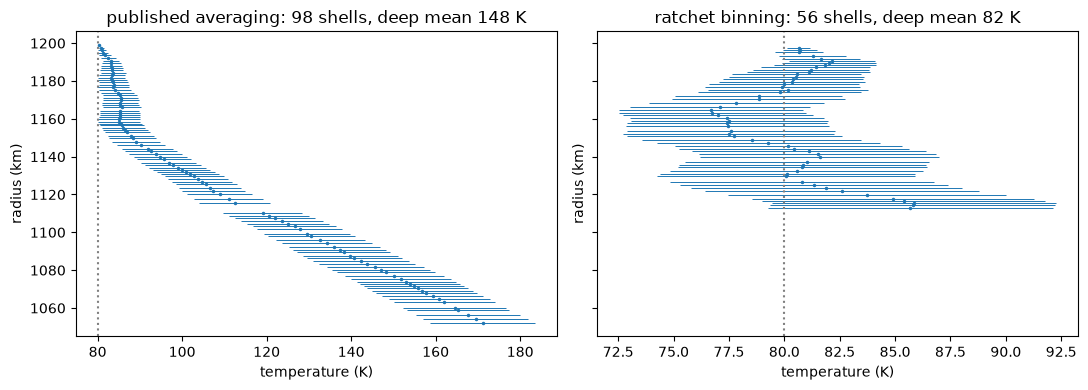

In [7]:
snr_low = 20.0
sigma_low = EPQ03.sigma_from_snr_h(snr_low, atm.h_h, 0.5)
phi_low, sig_low = EPQ03.add_noise(phi, sigma_low, np.random.default_rng(1))
bc_true = EPQ03.EY92PowerLawBoundary(r_h=atm.r_h, lambda_hi=atm.lambda_hi,
                                     b=atm.b, d=atm.d, order=atm.order)

# The averaging is applied up front here so the boundary can be placed by
# shadow radius; at moderate S/N (where flux-level boundary selection works)
# the one-liner is simply invert_light_curve(..., ratchet_binning=True).
runs, counts = {}, {}
for label, ratchet in [("published averaging", False), ("ratchet binning", True)]:
    ya, fa, sa, counts[label] = EPQ03.average_until_positive(
        y, phi_low, sig_low, ratchet=ratchet, return_counts=True)
    i_b_low = int(np.argmax(ya <= res.grid.y_b))        # boundary by shadow radius
    runs[label] = EPQ03.invert_light_curve(
        ya, fa, sa, d=atm.d, gas=atm.gas, m_p=M_p, order=atm.order,
        boundary=bc_true, i_b=i_b_low,
    )

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (label, r) in zip(axes, runs.items()):
    b = EPQ03.propagate_errors(r)
    EPQ03.plot_temperature(r, b, ax=ax)
    ax.axvline(80.0, color="gray", ls=":")
    t = r.temperature
    deep = t[2 * t.size // 3:]
    ax.set_title(f"{label}: {t.size} shells, deep mean {deep.mean():.0f} K")
    print(f"{label:20s} deep-third mean T = {deep.mean():6.1f} K "
          f"({t.size} shells)")
fig.tight_layout()

kp, kr = counts["published averaging"], counts["ratchet binning"]
print(f"bin sizes — published: max {kp.max()}, resets to 1 after merges "
      f"(monotone: {bool(np.all(np.diff(kp) >= 0))});")
print(f"            ratchet:   max {kr.max()}, monotone non-decreasing "
      f"({bool(np.all(np.diff(kr) >= 0))})")

## 7. Gotchas & citation

1. **Normalization first.** The inversion believes your 0 and 1 flux levels; errors there propagate into *everything* (deep pressure and density especially). On real data, establishing the baseline and background *is* the analysis.
2. **Choose $i_b$ explicitly on noisy data** (§3), and fit only the boundary parameters the data constrain.
3. **Small-λ guard:** boundary conditions with $\lambda_h \lesssim 6$ are rejected — the half-light relation has no real solution there (see the module docstring).
4. **Deep shells are binning-sensitive:** pressure/number-density deviations near the bottom of the inversion shrink as you carry it deeper or bin shells coarser (`min_shell`) — the behavior the paper predicts, not a bug.
5. **Low $(S/N)_H$ without `ratchet_binning=True` biases the deep profile hot** (§6) — the published averaging is the validated default, but check `bin_counts` and consider the ratchet whenever merges occur.
6. The published paper's Eq. (66) and Table 10 carry documented deviations (module docstring); the default `nu_h_method="ey92-4.28"` follows the paper's own printed digits.

**Cite:** Elliot, Person & Qu 2003, AJ 126, 1041 — and the package (`CITATION.cff`).
Companions: [overview](00_jlegroup_overview.ipynb) · [EY92](01_EY92_basics.ipynb) · [CE97](02_CE97_basics.ipynb)